# EDA Online Retail 
Данные взяты с [The UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/352/online+retail)

### О данных 
Данные содержат информацию  о транзакциях, произошедших в период с 01/12/2010 по 09/12/2011 для зарегистрированного в Великобритании интернет-магазина. Также указано, что основными товарами компаниия являются  уникальные подарки на все случаи жизни и многие клиенты компании являются оптовиками.

### Столбцы и информация, хранящееся в них:
- **`InvoiceNo`** - Номер транзакции(**'C'** в начале номера означает отмену транзакции)
- **`StockCode`** - Код продукта
- **`Description`** - Описание продукта
- **`Quantity`** - Количество купленных единиц товара
- **`InvoiceDate`** - Дата и время транзакции
- **`UnitPrice`** - Цена за единицу товара(в фунтах стерлингах)
- **`CustomerID`** - ID покупателя
- **`Country`** - Страна, в которой проживает покупатель

### Задачи 
1. Загрузка и предобработка данных.
2. Поиск закономерностей и визуализация
3. Подсчет метрик
4. Когортный анализ
5. RFM-анализ
.

### 1. Загрузка и предобработка данных

In [503]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
sns.set(style="whitegrid", color_codes=True)

%matplotlib inline

import warnings
warnings.simplefilter('ignore')

In [7]:
data = pd.read_excel('Online Retail.xlsx')
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
data[data.InvoiceNo.str.find('c').notna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


Избавимся от строк с пропущенными значениями в колонке CustomerID, преобразуем типы данных в столбцах InvoiceDate и CustomerId и создадим столбец FullAmount(полная сумма покупки)

In [12]:
data = data[data['CustomerID'].notna()]

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['CustomerID'] = data['CustomerID'].astype('int64')

data['FullAmount'] = data['Quantity'] * data['UnitPrice']
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  int64         
 7   Country      406829 non-null  object        
 8   FullAmount   406829 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 31.0+ MB


In [13]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,FullAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### 2. Поиск закономерностей и визуализация

In [15]:
data[['Quantity', 'UnitPrice','FullAmount']].describe()

,Quantity,UnitPrice,FullAmount
count,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,20.401854
std,248.693370,69.315162,427.591718
min,-80995.000000,0.000000,-168469.600000
25%,2.000000,1.250000,4.200000
50%,5.000000,1.950000,11.100000
75%,12.000000,3.750000,19.500000
max,80995.000000,38970.000000,168469.600000


In [16]:
print(f'Всего проведено транзакций: {data['InvoiceNo'].nunique()}')
print(f'Количество уникальных клиентов: {data['CustomerID'].nunique()}')
print(f'Количество стран, в которых проживают клиенты онйлан магазина: {data['Country'].nunique()}')

Всего проведено транзакций: 22190
Количество уникальных клиентов: 4372
Количество стран, в которых проживают клиенты онйлан магазина: 37


### Транзакции

In [18]:
transactions = data.groupby('InvoiceNo')[['Quantity','UnitPrice','FullAmount']].sum().reset_index()
transactions = transactions.sort_values(by='FullAmount')
transactions

,InvoiceNo,Quantity,UnitPrice,FullAmount
22185,C581484,-80995,2.08,-168469.60
18958,C541433,-74215,1.04,-77183.60
20237,C556445,-1,38970.00,-38970.00
19744,C550456,-9014,15.80,-22998.40
21416,C570556,-6480,30.41,-11816.64
...,...,...,...,...
8112,556917,15049,283.57,22775.93
12419,567423,12572,36.77,31698.16
7926,556444,60,649.50,38970.00
1909,541431,74215,1.04,77183.60


In [19]:
transactions.describe()

,Quantity,UnitPrice,FullAmount
count,22190.000000,22190.000000,22190.000000
mean,221.130599,63.443892,374.045327
std,1170.215301,311.076625,2018.482869
min,-80995.000000,0.000000,-168469.600000
25%,30.000000,11.400000,87.962500
50%,120.000000,35.295000,241.505000
75%,254.000000,75.282500,418.022500
max,80995.000000,38970.000000,168469.600000


In [20]:
purchases = transactions[transactions['FullAmount'] >= 0]
purchases.describe()

,Quantity,UnitPrice,FullAmount
count,18536.000000,18536.000000,18536.000000
mean,279.547691,66.896882,480.762187
std,976.796524,140.246721,1678.029352
min,1.000000,0.000000,0.000000
25%,74.000000,18.750000,157.930000
50%,155.000000,44.260000,303.020000
75%,291.000000,83.882500,471.660000
max,80995.000000,8142.750000,168469.600000


In [21]:
purchases[purchases['FullAmount'] == 0]

,InvoiceNo,Quantity,UnitPrice,FullAmount
12848,568384,1,0.0,0.0
2721,543599,16,0.0,0.0
17360,578841,12540,0.0,0.0
11301,564651,576,0.0,0.0


In [22]:
purchase_non_zero = purchases[purchases['FullAmount'] > 0]
purchase_non_zero[purchase_non_zero['FullAmount'] == purchase_non_zero['FullAmount'].min()]

,InvoiceNo,Quantity,UnitPrice,FullAmount
13792,570554,1,0.38,0.38


In [23]:
cancels = transactions[transactions['FullAmount'] < 0]
cancels.describe()

,Quantity,UnitPrice,FullAmount
count,3654.000000,3654.000000,3654.000000
mean,-75.207444,45.927573,-167.307633
std,1836.212969,698.300751,3179.611324
min,-80995.000000,0.010000,-168469.600000
25%,-11.000000,2.950000,-37.337500
50%,-4.000000,6.720000,-16.000000
75%,-1.000000,14.400000,-7.650000
max,-1.000000,38970.000000,-0.390000


In [24]:
def colors_from_values(values, palette_name):
    # normalize the values to range [0, 1]
    normalized = (values - min(values)) / (max(values) - min(values))
    # convert to indices
    indices = np.round(normalized * (len(values) - 1)).astype(np.int32)
    # use the indices to get the colors
    palette = sns.color_palette(palette_name, len(values))
    return np.array(palette).take(indices, axis=0)

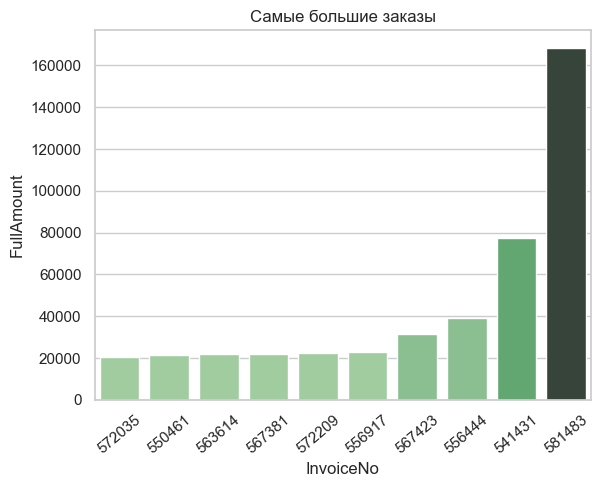

In [25]:
top = transactions.tail(10)
top['InvoiceNo'] = top['InvoiceNo'].astype(str)
sns.barplot(y=top['FullAmount'],x=top['InvoiceNo'], palette=colors_from_values(top['FullAmount'], "Greens_d"))
plt.xticks(rotation=40)
plt.title('Самые большие заказы')
plt.show()

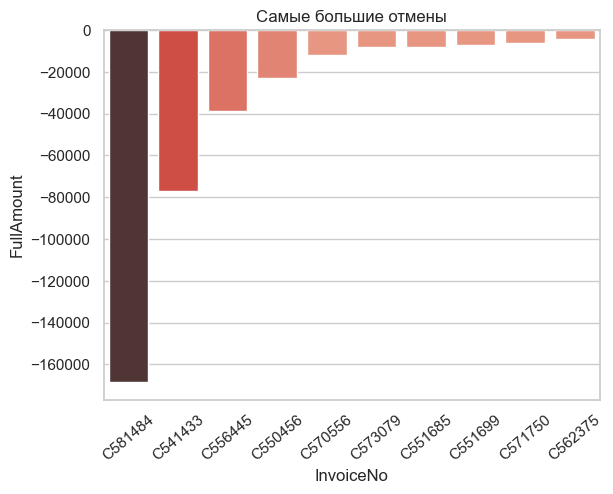

In [26]:
least = transactions.head(10)
least['InvoiceNo'] = least['InvoiceNo'].astype(str)
sns.barplot(y=least['FullAmount'],x=least['InvoiceNo'], palette=colors_from_values(abs(least['FullAmount']), "Reds_d"))
plt.xticks(rotation=40)
plt.title('Самые большие отмены')
plt.show()

### Покупатели

In [88]:
customers = data.groupby('CustomerID').agg({'Quantity': 'sum','UnitPrice':'sum','FullAmount':'sum','InvoiceNo':'count'}).reset_index()
customers = customers.sort_values(by='FullAmount')
customers.rename(columns={'InvoiceNo':'PurchaseCount'},inplace=True)
customers['CustomerID'] = customers['CustomerID'].astype('str')
customers

,CustomerID,Quantity,UnitPrice,FullAmount,PurchaseCount
3756,17448,-1,4287.63,-4287.63,1
2236,15369,-1,1592.49,-1592.49,1
1384,14213,-244,24.45,-1192.20,5
3870,17603,-31,1156.89,-1165.30,15
125,12503,-1,1126.00,-1126.00,1
...,...,...,...,...,...
55,12415,77242,2499.82,123725.45,778
1895,14911,77180,31060.66,132572.62,5903
3758,17450,69029,3320.09,187482.17,351
4233,18102,64122,5159.73,256438.49,433


In [90]:
customers.describe()

,Quantity,UnitPrice,FullAmount,PurchaseCount
count,4372.000000,4372.000000,4372.000000,4372.000000
mean,1122.344007,322.008226,1898.459701,93.053294
std,4672.790720,1284.783098,8219.345141,232.471608
min,-303.000000,0.000000,-4287.630000,1.000000
25%,153.000000,52.865000,293.362500,17.000000
50%,365.000000,130.095000,648.075000,42.000000
75%,962.250000,302.332500,1611.725000,102.000000
max,196719.000000,41376.330000,279489.020000,7983.000000


In [92]:
customers['FullAmount'][-10:]

2192     59419.34
1005     62653.10
3202     65892.08
3801     88125.38
1345    113384.14
55      123725.45
1895    132572.62
3758    187482.17
4233    256438.49
1703    279489.02
Name: FullAmount, dtype: float64

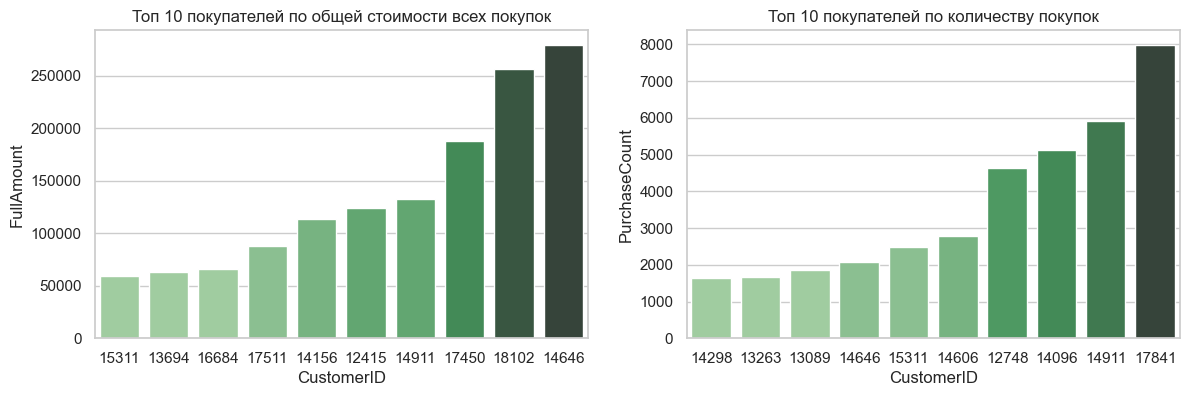

In [102]:
fig, ax = plt.subplots(1,2, figsize=(14, 4) )
sns.barplot(y=customers['FullAmount'][-10:],x=customers['CustomerID'][-10:], palette=colors_from_values(customers['FullAmount'][-10:], "Greens_d"),ax=ax[0])
ax[0].set_title('Топ 10 покупателей по общей стоимости всех покупок')

customers_count = customers.sort_values(by='PurchaseCount')
sns.barplot(y=customers_count['PurchaseCount'][-10:],x=customers_count['CustomerID'][-10:], palette=colors_from_values(customers_count['PurchaseCount'][-10:], "Greens_d"),ax=ax[1])
ax[1].set_title('Топ 10 покупателей по количеству покупок')

plt.show()

### Страны

In [155]:
countries = data.groupby('Country').agg({'InvoiceNo':'count','FullAmount':'sum'}).sort_values(by='FullAmount',ascending=False)
countries.head(10)

,InvoiceNo,FullAmount
Country,,
United Kingdom,361878,6767873.394
Netherlands,2371,284661.540
EIRE,7485,250285.220
Germany,9495,221698.210
France,8491,196712.840
Australia,1259,137077.270
Switzerland,1877,55739.400
Spain,2533,54774.580
Belgium,2069,40910.960


In [157]:
countries.describe()

,InvoiceNo,FullAmount
count,37.000000,3.700000e+01
mean,10995.378378,2.243261e+05
std,59331.636449,1.108139e+06
min,10.000000,1.311700e+02
25%,127.000000,1.902280e+03
50%,358.000000,1.015432e+04
75%,1259.000000,3.659591e+04
max,361878.000000,6.767873e+06


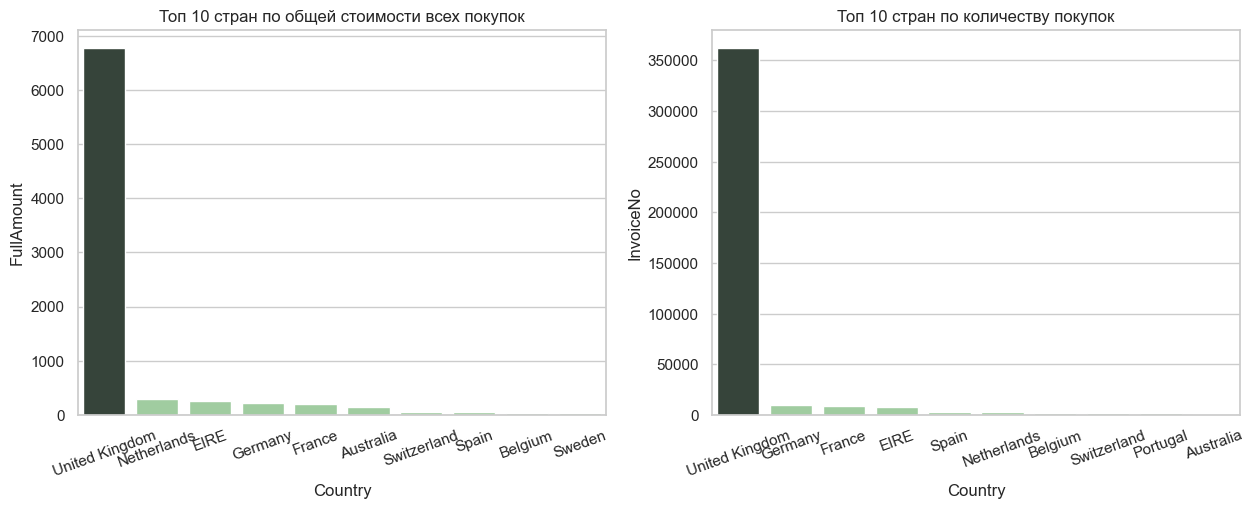

In [226]:
fig, ax = plt.subplots(1,2, figsize=(15, 5) )
sns.barplot(y=countries['FullAmount'][:10] / 1000,x=countries.index[:10], palette=colors_from_values(countries['FullAmount'][:10], "Greens_d"),ax=ax[0])
ax[0].set_title('Топ 10 стран по общей стоимости всех покупок')
ax[0].tick_params(axis='x', labelrotation=20)

countries_count= countries.sort_values(by='InvoiceNo',ascending=False)
sns.barplot(y=countries_count['InvoiceNo'][:10],x=countries_count.index[:10], palette=colors_from_values(countries_count['InvoiceNo'][:10], "Greens_d"),ax=ax[1])
ax[1].set_title('Топ 10 стран по количеству покупок')
ax[1].tick_params(axis='x', labelrotation=20)

plt.show()

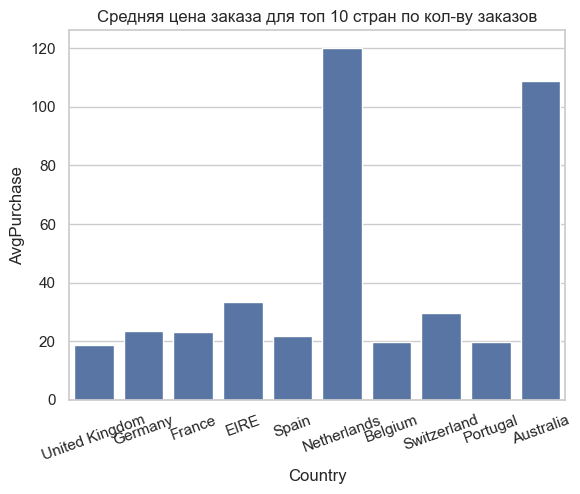

In [171]:
countries_count['AvgPurchase'] = countries_count['FullAmount'] / countries_count['InvoiceNo']
sns.barplot(y=countries_count['AvgPurchase'][:10],x=countries_count.index[:10])
plt.title('Средняя цена заказа для топ 10 стран по кол-ву заказов')
plt.xticks(rotation=20)
plt.show()

### Временные промежутки

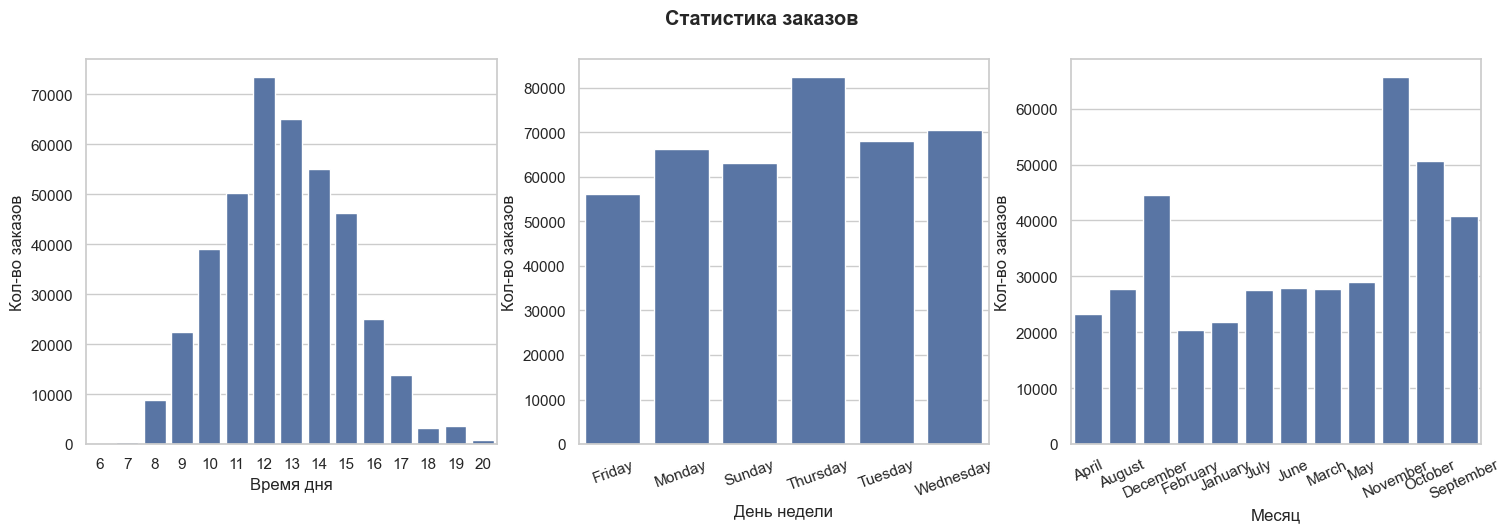

In [252]:
month = data.groupby(data['InvoiceDate'].dt.month_name())['InvoiceNo'].count()
day_of_week = data.groupby(data['InvoiceDate'].dt.day_name())['InvoiceNo'].count()
hour = data.groupby(data['InvoiceDate'].dt.hour)['InvoiceNo'].count()

fig, ax = plt.subplots(1,3, figsize=(18, 5) )

fig.suptitle('Статистика заказов', fontweight='heavy')

sns.barplot(hour,ax=ax[0],)
ax[0].set_xlabel('Время дня')
ax[0].set_ylabel('Кол-во заказов')

sns.barplot(day_of_week,ax=ax[1])
ax[1].tick_params(axis='x', labelrotation=20)
ax[1].set_xlabel('День недели')
ax[1].set_ylabel('Кол-во заказов')

sns.barplot(month,ax=ax[2])
ax[2].tick_params(axis='x', labelrotation=25)
ax[2].set_xlabel('Месяц')
ax[2].set_ylabel('Кол-во заказов')

plt.show()

### Когортный анализ удержания

In [456]:
cohorts = data[['CustomerID', 'InvoiceDate']]

cohorts['order_month'] = cohorts.InvoiceDate.apply(lambda x: x.strftime('%Y-%m'))

join_month = pd.DataFrame(cohorts.groupby('CustomerID')['InvoiceDate'].min().apply(lambda x: x.strftime('%Y-%m'))).rename(columns={'InvoiceDate': 'join_month'})
cohorts = pd.merge(cohorts,join_month, on=['CustomerID'])

cohorts.head()

,CustomerID,InvoiceDate,order_month,join_month
0,17850,2010-12-01 08:26:00,2010-12,2010-12
1,17850,2010-12-01 08:26:00,2010-12,2010-12
2,17850,2010-12-01 08:26:00,2010-12,2010-12
3,17850,2010-12-01 08:26:00,2010-12,2010-12
4,17850,2010-12-01 08:26:00,2010-12,2010-12


In [457]:
cohorts_1 = cohorts.groupby(['join_month', 'order_month']) \
                   .agg({'CustomerID':pd.Series.nunique, 'InvoiceDate':pd.Series.count}) \
                    .rename(columns={'CustomerID':'total_customers','InvoiceDate':'total_orders'})
cohorts_1

total_customers  total_orders
join_month order_month                               
2010-12    2010-12                  948         26850
           2011-01                  362         10881
           2011-02                  317          9183
           2011-03                  367         12111
           2011-04                  341         10092
...                                 ...           ...
2011-10    2011-11                   93          3643
           2011-12                   46           907
2011-11    2011-11                  321         11249
           2011-12                   43          1152
2011-12    2011-12                   41           996

[91 rows x 2 columns]

In [482]:
cohorts_2 = cohorts_1.reset_index()
cohorts_2['cohort_period'] = cohorts_2.groupby('join_month')['order_month'].rank(method='dense').astype('int16')
cohorts_2.set_index(['cohort_period', 'join_month'], inplace=True)
cohorts_2.head()

,,order_month,total_customers,total_orders
cohort_period,join_month,,,
1,2010-12,2010-12,948,26850
2,2010-12,2011-01,362,10881
3,2010-12,2011-02,317,9183
4,2010-12,2011-03,367,12111
5,2010-12,2011-04,341,10092


In [486]:
cohort_group_size = cohorts_2['total_customers'].groupby(level=1).first()
cohorts_2['total_customers'].unstack(0)

cohort_period,1,2,3,4,5,6,7,8,9,10,11,12,13
join_month,,,,,,,,,,,,,
2010-12,948.0,362.0,317.0,367.0,341.0,376.0,360.0,336.0,336.0,374.0,354.0,474.0,260.0
2011-01,421.0,101.0,119.0,102.0,138.0,126.0,110.0,108.0,131.0,146.0,155.0,63.0,NaN
2011-02,380.0,94.0,73.0,106.0,102.0,94.0,97.0,107.0,98.0,119.0,35.0,NaN,NaN
2011-03,440.0,84.0,112.0,96.0,102.0,78.0,116.0,105.0,127.0,39.0,NaN,NaN,NaN
2011-04,299.0,68.0,66.0,63.0,62.0,71.0,69.0,78.0,25.0,NaN,NaN,NaN,NaN
2011-05,279.0,66.0,48.0,48.0,60.0,68.0,74.0,29.0,NaN,NaN,NaN,NaN,NaN
2011-06,235.0,49.0,44.0,64.0,58.0,79.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,191.0,40.0,39.0,44.0,52.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,167.0,42.0,42.0,42.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [488]:
retention_rate = cohorts_2['total_customers'].unstack(0).divide(cohort_group_size, axis=0)
retention_rate

cohort_period,1,2,3,4,5,6,7,8,9,10,11,12,13
join_month,,,,,,,,,,,,,
2010-12,1.0,0.381857,0.334388,0.387131,0.359705,0.396624,0.379747,0.354430,0.354430,0.394515,0.373418,0.500000,0.274262
2011-01,1.0,0.239905,0.282660,0.242280,0.327791,0.299287,0.261283,0.256532,0.311164,0.346793,0.368171,0.149644,NaN
2011-02,1.0,0.247368,0.192105,0.278947,0.268421,0.247368,0.255263,0.281579,0.257895,0.313158,0.092105,NaN,NaN
2011-03,1.0,0.190909,0.254545,0.218182,0.231818,0.177273,0.263636,0.238636,0.288636,0.088636,NaN,NaN,NaN
2011-04,1.0,0.227425,0.220736,0.210702,0.207358,0.237458,0.230769,0.260870,0.083612,NaN,NaN,NaN,NaN
2011-05,1.0,0.236559,0.172043,0.172043,0.215054,0.243728,0.265233,0.103943,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.208511,0.187234,0.272340,0.246809,0.336170,0.102128,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.209424,0.204188,0.230366,0.272251,0.115183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.251497,0.251497,0.251497,0.137725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


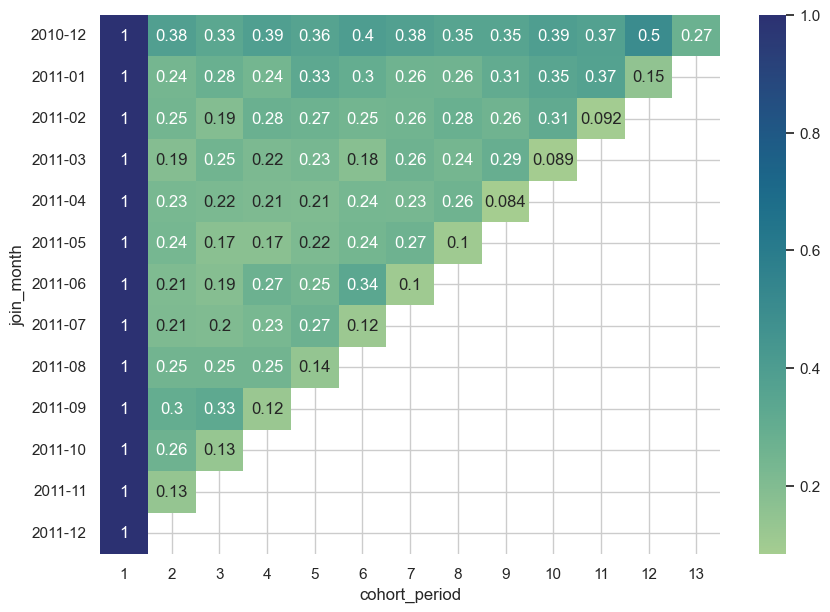

In [490]:
plt.figure(figsize=(10, 7))
sns.heatmap(retention_rate,annot=True,cmap="crest")
plt.show()

### RFM-анализ

In [541]:
print('Начальная дата', data['InvoiceDate'].min(), 'Конечная дата', data['InvoiceDate'].max())

Начальная дата 2010-12-01 08:26:00 Конечная дата 2011-12-09 12:50:00


In [573]:
df =data[~data['InvoiceNo'].str.contains('C', na = False)]
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,FullAmount
count,397924.000000,397924,397924.000000,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171,22.394749
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.420210,NaN,22.096788,1713.169877,309.055588


In [576]:
recency = (dt.datetime(2010, 12, 9) - data.groupby('CustomerID').agg({'InvoiceDate':'max'})).rename(columns = {'InvoiceDate':'Recency'})
recency['Recency'] = abs(recency['Recency'].dt.days)
recency.head()

,Recency
CustomerID,
12346,41
12347,364
12348,291
12349,348
12350,56


In [578]:
freq = data.groupby('CustomerID').agg({'InvoiceDate':'nunique'}).rename(columns={'InvoiceDate': 'Frequency'})
freq.head()

,Frequency
CustomerID,
12346,2
12347,7
12348,4
12349,1
12350,1


In [580]:
monetary = data.groupby('CustomerID').agg({'FullAmount':'sum'}).rename(columns={'FullAmount':'Monetary'})
monetary.head()

,Monetary
CustomerID,
12346,0.00
12347,4310.00
12348,1797.24
12349,1757.55
12350,334.40


In [582]:
rfm = pd.concat([recency, freq, monetary],  axis=1)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,41,2,0.00
12347,364,7,4310.00
12348,291,4,1797.24
12349,348,1,1757.55
12350,56,1,334.40


In [593]:
rfm['RecencyScore'] = pd.qcut(rfm['Recency'], 3, labels = [3, 2, 1])

rfm['FrequencyScore']= pd.qcut(rfm['Frequency'].rank(method="first"),3, labels=[1,2,3])

rfm['MonetaryScore'] = pd.qcut(rfm['Monetary'], 3, labels = [1, 2, 3])


rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
CustomerID,,,,,,,
12346,41,2,0.00,3,1,1,521
12347,364,7,4310.00,1,3,3,145
12348,291,4,1797.24,2,2,3,434
12349,348,1,1757.55,1,1,3,214
12350,56,1,334.40,3,1,1,512


In [595]:
rfm['RFM_SCORE'] = (rfm['RecencyScore'].astype(str) + 
                     rfm['FrequencyScore'].astype(str) + 
                     rfm['MonetaryScore'].astype(str))
rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
CustomerID,,,,,,,
12346,41,2,0.00,3,1,1,311
12347,364,7,4310.00,1,3,3,133
12348,291,4,1797.24,2,2,3,223
12349,348,1,1757.55,1,1,3,113
12350,56,1,334.40,3,1,1,311


In [599]:
rfm_graph = rfm.reset_index() \
               .groupby('RFM_SCORE', as_index=False) \
               .agg({'CustomerID': 'count'}) \
               .rename(columns={'CustomerID': 'num_of_customers'})
rfm_graph.head()

,RFM_SCORE,num_of_customers
0,111,120
1,112,38
2,113,9
3,121,100
4,122,241


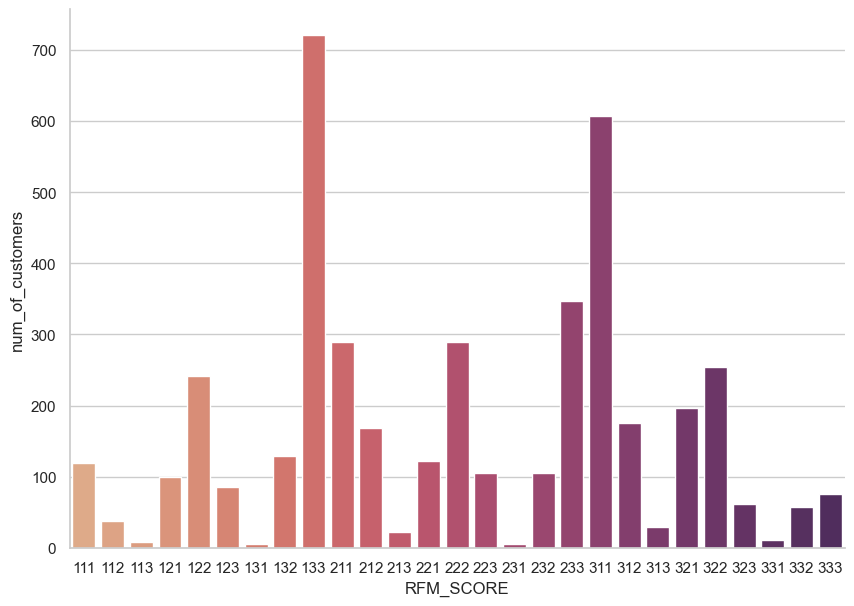

In [605]:
sns.color_palette("flare", as_cmap=True)
plt.figure(figsize=(10, 7))

sns.barplot(data=rfm_graph, x='RFM_SCORE', y='num_of_customers', palette="flare")
sns.despine()